In [1]:
!pip install -q s3fs pyarrow plotly nbformat

In [2]:
import pandas as pd

cols = ['step', 'step_day', 'type', 'amount', 'isfraud', 'isflaggedfraud']
df = pd.read_parquet('s3://mgmt59900-g3-paysim/curated/silver/', columns=cols)
print(df.shape)

(6362620, 6)


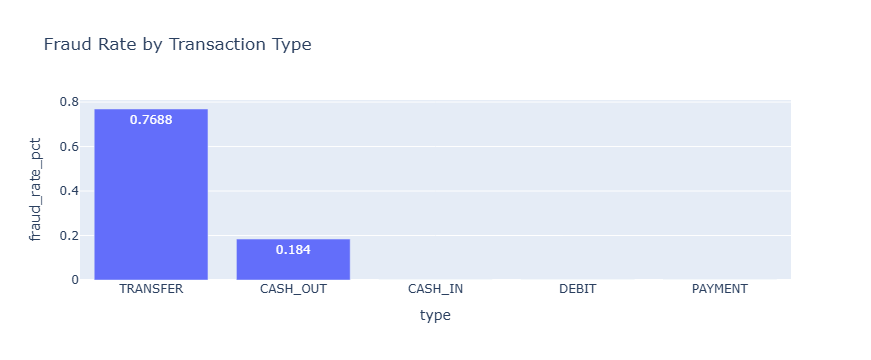

       type  txn_count  fraud_count  fraud_rate_pct
4  TRANSFER     532909         4097          0.7688
1  CASH_OUT    2237500         4116          0.1840
0   CASH_IN    1399284            0          0.0000
2     DEBIT      41432            0          0.0000
3   PAYMENT    2151495            0          0.0000


In [4]:
# Generate chart of fraud rate by transaction type - Query (a)
import plotly.express as px

df1 = df.groupby('type').agg(
    txn_count=('isfraud', 'count'),
    fraud_count=('isfraud', 'sum')
).reset_index()
df1['fraud_rate_pct'] = round(100 * df1['fraud_count'] / df1['txn_count'], 4)
df1 = df1.sort_values('fraud_rate_pct', ascending=False)

fig1 = px.bar(df1, x='type', y='fraud_rate_pct', text='fraud_rate_pct',
              title='Fraud Rate by Transaction Type')
fig1.show()
print(df1)

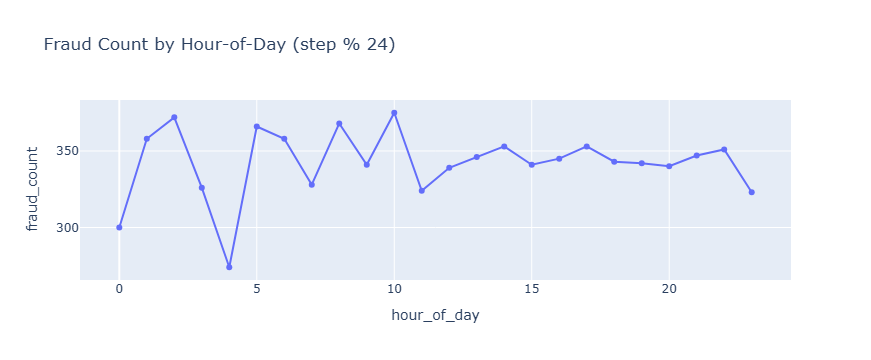

    hour_of_day  txn_count  fraud_count
0             0      71587          300
1             1      27111          358
2             2       9018          372
3             3       2007          326
4             4       1241          274
5             5       1641          366
6             6       3420          358
7             7       8988          328
8             8      26915          368
9             9     283518          341
10           10     425729          375
11           11     445992          324
12           12     483418          339
13           13     468474          346
14           14     439653          353
15           15     416686          341
16           16     441612          345
17           17     439941          353
18           18     580509          343
19           19     647814          342
20           20     553728          340
21           21     247806          347
22           22     194555          351
23           23     141257          323


In [6]:
# Generate chart of fraud by hour of day - Query (b)
df2 = df.copy()
df2['hour_of_day'] = df2['step'] % 24
df2 = df2.groupby('hour_of_day').agg(
    txn_count=('isfraud', 'count'),
    fraud_count=('isfraud', 'sum')
).reset_index()

fig2 = px.line(df2, x='hour_of_day', y='fraud_count', markers=True,
               title='Fraud Count by Hour-of-Day (step % 24)')
fig2.show()
print(df2)

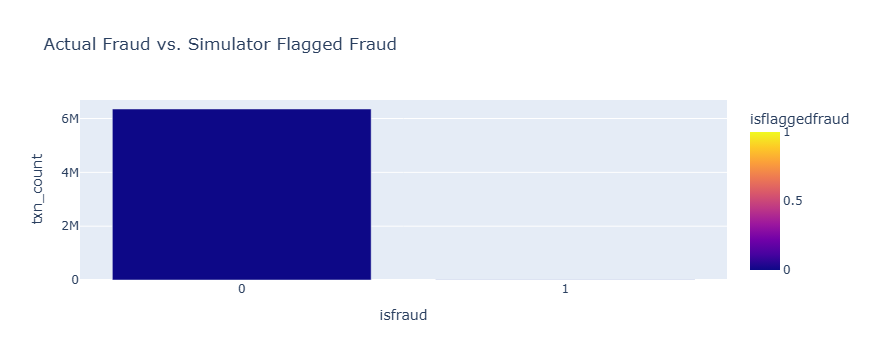

   isfraud  isflaggedfraud  txn_count
0        0               0    6354407
1        1               0       8197
2        1               1         16


In [8]:
# Generate chart of flagged-vs-actual fraud comparison - Query (d)
df3 = df.groupby(['isfraud', 'isflaggedfraud']).size().reset_index(name='txn_count')

fig3 = px.bar(df3, x='isfraud', y='txn_count', color='isflaggedfraud', barmode='group',
              title='Actual Fraud vs. Simulator Flagged Fraud')
fig3.show()
print(df3)


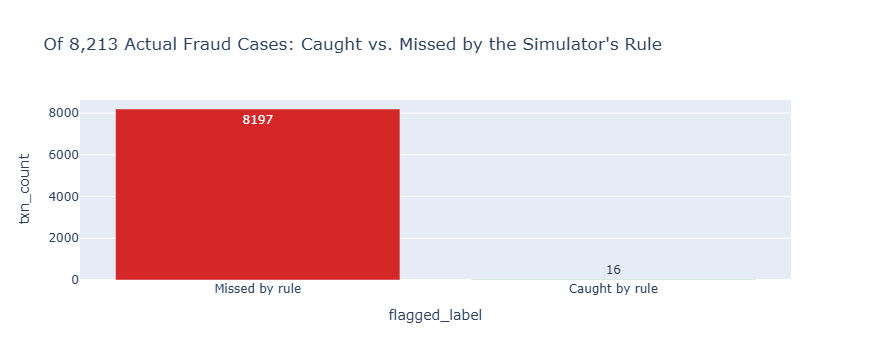

In [9]:
# Generate chart of fraud cases detected vs missed by the Paysim simulator's rule based approach
df3_fraud_only = df3[df3['isfraud'] == 1].copy()
df3_fraud_only['flagged_label'] = df3_fraud_only['isflaggedfraud'].map({0: 'Missed by rule', 1: 'Caught by rule'})

fig3 = px.bar(df3_fraud_only, x='flagged_label', y='txn_count', text='txn_count',
              title='Of 8,213 Actual Fraud Cases: Caught vs. Missed by the Simulator\'s Rule',
              color='flagged_label', color_discrete_map={'Missed by rule': '#d62728', 'Caught by rule': '#2ca02c'})
fig3.update_layout(showlegend=False)
fig3.show()

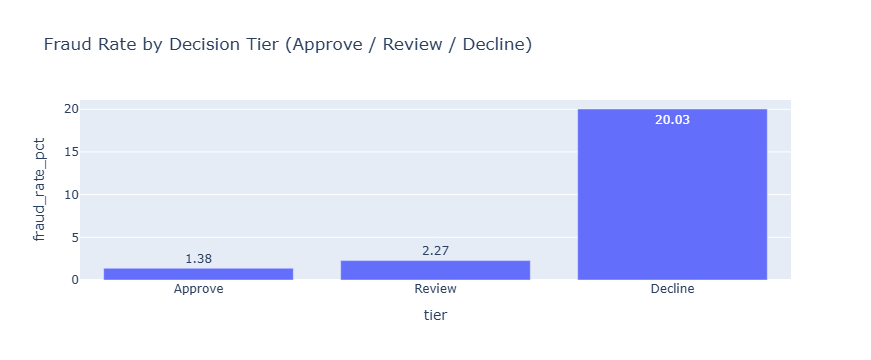

      tier  txn_count  fraud_caught  fraud_rate_pct
0  Approve       7262           100            1.38
1   Review      40893           927            2.27
2  Decline       3131           627           20.03


In [12]:
# Generate chart of fraud rate by decision tier - Numbers extracted from model implementation's notebook 
# phase_e_fraud_model.ipynb

import pandas as pd

tier_data = pd.DataFrame({
    'tier': ['Approve', 'Review', 'Decline'],
    'txn_count': [7262, 40893, 3131],
    'fraud_caught': [100, 927, 627],
})
tier_data['fraud_rate_pct'] = round(100 * tier_data['fraud_caught'] / tier_data['txn_count'], 2)

fig4 = px.bar(tier_data, x='tier', y='fraud_rate_pct', text='fraud_rate_pct',
              title='Fraud Rate by Decision Tier (Approve / Review / Decline)',
              category_orders={'tier': ['Approve', 'Review', 'Decline']})
fig4.show()
print(tier_data)